In [1]:
# %matplotlib widget
import numpy as np
from sim_library.constants import k_eff, dR, m, kb, omega_eg
from scipy.constants import hbar, pi
import matplotlib.pyplot as plt
from pathlib import Path
from sim_library.simulation import simulate_pulses_single_atom, simulate_pulses_single_atom_analyt, simulate_pulses_p_dist, simulate_alg_cooling, simulate_alg_cooling_custom
from sim_library.sequences import RR3_gate, PulseSequence, UpPulse, DownPulse, FreeEvolution, gen_MDFEup_seq, gen_MDFEdown_seq, RR3_adjMDFE_500kHz
from sim_library.plotting import plot_state_trajectories, plot_bloch, plot_hist, save_gif, plot_coolingcycles_22, fit_gaussian, fit_gaussian_custom, display_table_compare, plot_bloch_multi
from sim_library.data_io import load_p_dists

[0.0098281  0.04908682 0.08813411 0.12681305]
0.03925872834333184


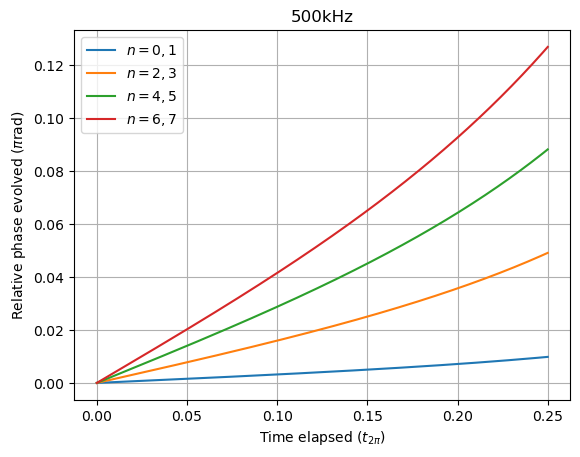

In [2]:
### Numerical

# Rabi frequency in 2*pi*Hz units
rabi_freq = 2*pi*5e5
rabi_time = 2*pi/rabi_freq # 2pi pulse time

# Set total resolution of time steps
n_steps = 1000

indices = [8,10,12,14]

# Define basis: p in units of hbar*k (even p = ground state)
p_min = -8
p_max = 8
basis = np.arange(p_min, p_max + 1)


# Set doppler shift
atom_veloc = 0.0 # Stationary

pulse_seq1 = PulseSequence()

pulse1 = UpPulse(laser_det=np.full(n_steps,0),phase=np.full(n_steps, pi/2), rabi_freq=np.full(n_steps,rabi_freq), duration=rabi_time/4)

pulse_seq1.add_pulses([pulse1])


for i in range(len(indices)):
    initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
    initial_state[indices[i]] = 1
    initial_state[indices[i]+1] = 0
    initial_state = initial_state/ np.linalg.norm(initial_state) # Normalise
    

    wave_func, times = simulate_pulses_single_atom(pulse_seq=pulse_seq1, basis=basis, initial_state=initial_state, d_shift=k_eff*atom_veloc)

    if i == 0:
        wave_funcs = np.zeros((len(indices),len(times),2), dtype=np.complex128)

    wave_funcs[i,:,:] = wave_func[:,indices[i]:indices[i]+2]


angles = (np.angle(wave_funcs[:,:,1]) - np.angle(wave_funcs[:,:,0]))

angles = np.unwrap(angles, axis=1)

fig, ax = plt.subplots()
ax.plot(times/(rabi_time),angles.transpose()/pi)
# ax.set_yticks([0,0.02,0.04,0.06,0.08,0.1,0.12],[r'0.00', r'0.02$\pi$', r'0.04$\pi$', r'0.06$\pi$', r'0.08$\pi$', r'0.1$\pi$', r'0.12$\pi$'])
# ax.set_ylim(-0.005,0.12)
ax.grid()
ax.set_ylabel(r'Relative phase evolved ($\pi$rad)')
ax.set_xlabel(r'Time elapsed ($t_{2\pi}$)')
ax.legend([r'$n=0,1$',r'$n=2,3$',r'$n=4,5$',r'$n=6,7$'])
ax.set_title('500kHz')
# plt.ylim(0,2.1)
# plt.xlim(0,(rabi_time/2)*1.1)

print(angles[:,-1]/pi)
print((angles[1,-1]-angles[0,-1])/pi)




# display_table_compare(basis=basis, init_state=wave_func[0,:], final_state=wave_func[-1,:])
# plot_bloch(wave_func=wave_func[:,indices[0]:indices[1]+1], show=True)

In [45]:
### Analytical
# def bsphase_nearres(n, omega_R):
#     return (2*n+1)*dR/omega_R

# def bsphase(n, omega_R):
#     squarrt = np.sqrt(omega_R**2+((2*n+1)*dR)**2)
#     return np.arctan(np.tan(pi*squarrt/4/omega_R)*(2*n+1)*dR/squarrt)

def bsphase_nearres(detuning, omega_R):
    return detuning/omega_R

def bsphase(detuning, omega_R):
    squarrt = np.sqrt((omega_R**2)+(detuning**2))
    return np.arctan(np.tan(pi*squarrt/4/omega_R)*detuning/squarrt)

def bsphase2(detuning, omega_R):
    squarrt = np.sqrt((omega_R**2)+(detuning**2))
    return np.arctan2(np.sin(pi*squarrt/4/omega_R)*detuning/squarrt, np.cos(pi*squarrt/4/omega_R))

def c1amp(detuning, omega_R):
    squarrt = np.sqrt((omega_R**2)+(detuning**2))
    return (omega_R**2/((omega_R**2)+(detuning**2)))*(np.sin(pi*squarrt/4/omega_R)**2)

Analytical: [0.0098281  0.04908682 0.08813411 0.12681305]
Numerical: [0.0098281  0.04908682 0.08813411 0.12681305]
Linear approx: [0.00982854 0.04914272 0.0884569  0.12777108]


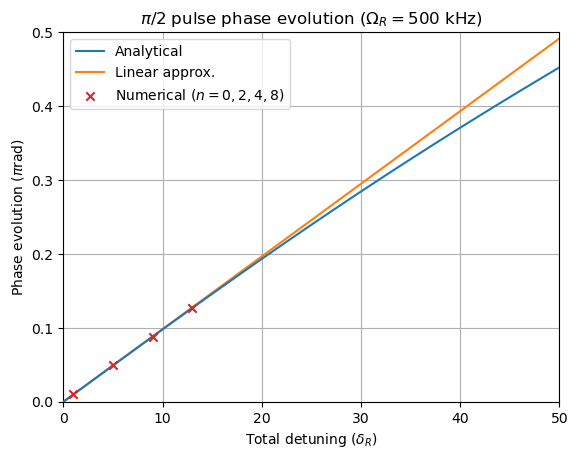

In [16]:
# Rabi frequency in 2*pi*Hz units
rabi_freq = 2*pi*5e5
rabi_time = 2*pi/rabi_freq # 2pi pulse time

state_ns = np.array([0,2,4,6])
print('Analytical:',bsphase((2*state_ns+1)*dR,omega_R=rabi_freq)/pi)
print('Numerical:', angles[:,-1]/pi)
print('Linear approx:', bsphase_nearres((2*state_ns+1)*dR,omega_R=rabi_freq)/pi)

dets = np.linspace(0,50*dR,100)

phases_appr = bsphase_nearres(dets, omega_R=rabi_freq)/pi
phases = bsphase2(dets, omega_R=rabi_freq)/pi

fig, ax  = plt.subplots()
ax.plot(dets/dR, phases, zorder=10)
ax.plot(dets/dR, phases_appr)
ax.scatter((2*state_ns+1), angles[:,-1]/pi, c='tab:red', zorder=20, marker='x')
ax.set_title(r'$\pi/2$ pulse phase evolution ($\Omega_R=500$ kHz)')
ax.grid()
ax.set_ylim(0,0.5)
ax.set_xlim(0,50)
ax.set_ylabel(r'Phase evolution ($\pi$rad)')
ax.set_xlabel(r'Total detuning ($\delta_R$)')
ax.legend([r'Analytical', r'Linear approx.', 'Numerical ($n=0,2,4,8$)'])



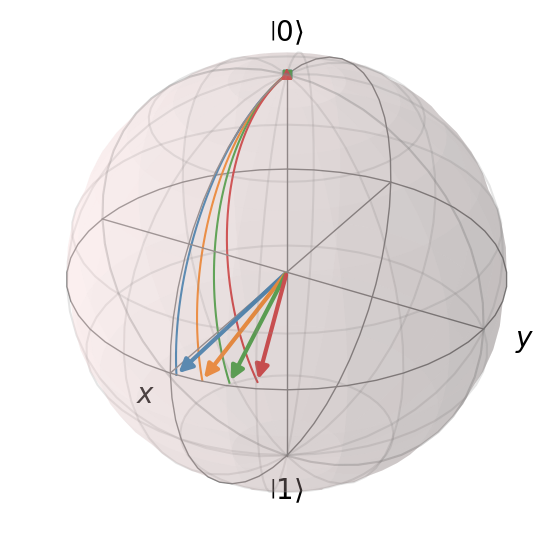

In [6]:
# %matplotlib widget
b, fig = plot_bloch_multi(wave_func=wave_funcs, show=True)
# fig


[0.76822481 0.67974204 0.60216503 0.53435228 0.47517565 0.42355414
 0.3784929  0.33910314 0.30460618 0.27432809 0.24768976 0.22419559
 0.2034222  0.18500802 0.16864414 0.15406629 0.14104801 0.12939487
 0.11893961 0.10953796 0.10106528 0.09341354 0.08648898 0.08020997
 0.07450528 0.06931267 0.06457757 0.06025205 0.05629394 0.05266603
 0.04933543 0.04627303 0.04345299 0.04085232 0.03845057 0.03622946
 0.03417266 0.03226557 0.03049505 0.02884932 0.02731777 0.02589084
 0.0245599  0.02331714 0.02215548 0.02106853 0.02005046 0.01909598
 0.01820027 0.01735894 0.01656797 0.01582371 0.0151228  0.01446217
 0.01383899 0.01325069 0.01269489 0.01216939 0.01167218 0.01120141
 0.01075535 0.01033243 0.00993117 0.00955023 0.00918833 0.00884433
 0.00851713 0.00820573 0.0079092  0.00762666 0.00735732 0.0071004
 0.00685522 0.00662111 0.00639746 0.0061837  0.00597928 0.00578371
 0.00559652 0.00541727 0.00524554 0.00508095 0.00492312 0.00477173
 0.00462644 0.00448696 0.00435299 0.00422427 0.00410055 0.00398

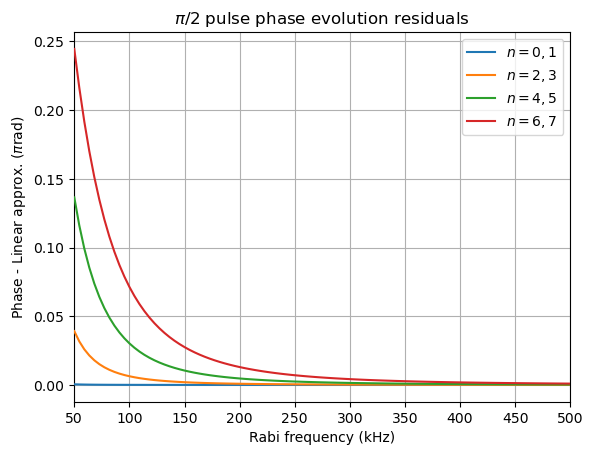

In [43]:
# Rabi frequency in 2*pi*Hz units
rabi_freq = 2*pi*5e5
rabi_time = 2*pi/rabi_freq # 2pi pulse time

state_ns = np.array([0,2,4,6])

# rabis = 2*pi*np.logspace(5,6,1000, base=10)
rabis = 2*pi*np.linspace(0.5e5, 5e5, 100)

phases = np.zeros((len(state_ns), len(rabis)))
phases_lin = np.zeros((len(state_ns), len(rabis)))
                  
for i in range(len(state_ns)):
    phases[i,:] = bsphase2((2*state_ns[i]+1)*dR, omega_R=rabis)
    phases_lin[i,:] = bsphase_nearres((2*state_ns[i]+1)*dR, omega_R=rabis)

phases = np.flip(np.unwrap(np.flip(phases, axis=1), axis=1,), axis=1)

residuals = phases_lin - phases



fig, ax  = plt.subplots()
# ax.semilogx(rabis/(2*pi), residuals.transpose()/pi, zorder=10)
ax.plot(rabis/(2*pi)/1000, residuals.transpose()/pi, zorder=10)


print(residuals[3,:])
ax.set_title(r'$\pi/2$ pulse phase evolution residuals')
ax.grid()
# ax.set_ylim(0,0.5)
ax.set_xlim(50,500)
ax.set_ylabel(r'Phase - Linear approx. ($\pi$rad)')
ax.set_xlabel(r'Rabi frequency (kHz)')
ax.legend([r'$n=0,1$',r'$n=2,3$',r'$n=4,5$',r'$n=6,7$'], loc='upper right')
# ax.legend([r'Analytical', r'Linear approx.', 'Numerical ($n=0,2,4,8$)'])



(0.0, 50.0)

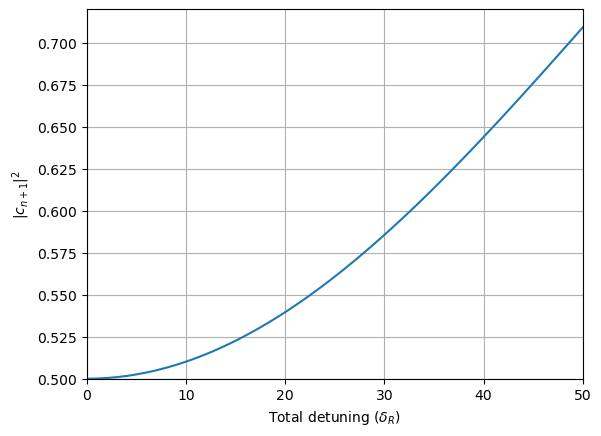

In [51]:
# Rabi frequency in 2*pi*Hz units
rabi_freq = 2*pi*5e5
rabi_time = 2*pi/rabi_freq # 2pi pulse time

detunings = np.linspace(0,50*dR)

amps = c1amp(detuning=detunings, omega_R=rabi_freq)

fig, ax  = plt.subplots()
ax.plot(detunings/dR,1-amps)
ax.set_xlabel(r'Total detuning ($\delta_R$)')
ax.set_ylabel(r'${|c_{n+1}|}^2$')
ax.grid()
ax.set_ylim(0.5,0.72)
ax.set_xlim(0,50)

(50.0, 500.0)

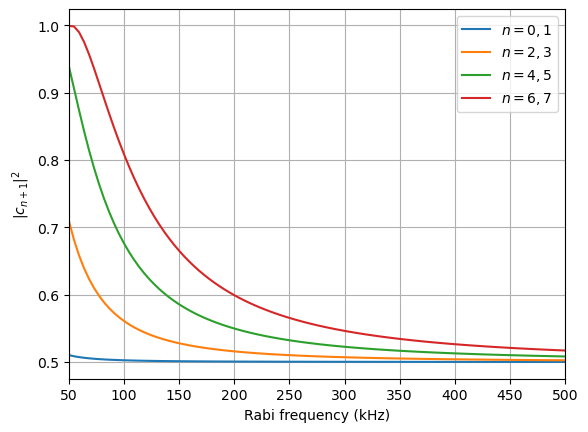

In [57]:
# Rabi frequency in 2*pi*Hz units
rabi_freq = 2*pi*5e5
rabi_time = 2*pi/rabi_freq # 2pi pulse time

state_ns = np.array([0,2,4,6])
rabis = 2*pi*np.linspace(0.5e5, 5e5, 100)

amps = np.zeros((len(state_ns), len(rabis)))

for i in range(len(state_ns)):
    amps[i,:] = c1amp((2*state_ns[i]+1)*dR, omega_R=rabis)


fig, ax  = plt.subplots()
ax.plot(rabis/(2*pi*1000),1-amps.transpose())
ax.set_ylabel(r'${|c_{n+1}|}^2$')
ax.set_xlabel(r'Rabi frequency (kHz)')
ax.legend([r'$n=0,1$',r'$n=2,3$',r'$n=4,5$',r'$n=6,7$'], loc='upper right')
ax.grid()
ax.set_xlim(50,500)
